# Simple TCN for conductivity forecasting

This notebook contains only the Temporal Convolutional Network (TCN) experiment. It reads the five conductivity series from Apache Jena Fuseki and forecasts conductivity at the Indusii industrial site.

The model is intentionally simple:

1. Read the five sensors from Fuseki.
2. Put them on a regular 15-minute grid.
3. Apply a trailing two-hour mean to reduce quarter-hour measurement noise.
4. Give the network the previous 72 hours from every sensor.
5. Predict the change at Indusii at one chosen forecast horizon.
6. Compare the TCN with persistence: assuming conductivity does not change.
7. Mask different parts of the history to see which lag ranges influence the model.

No 42-hour propagation delay is manually imposed. The network receives the complete history and can learn useful delays through its dilated causal convolutions.

## 1. Imports and experiment settings

The default experiment predicts conductivity **4 hours ahead** from the preceding **72 hours**. Change `FORECAST_HOURS` to `1` if you want the easier one-hour experiment.

Required packages: `pandas`, `numpy`, `matplotlib`, `scikit-learn`, `SPARQLWrapper`, and `tensorflow`.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from SPARQLWrapper import JSON, SPARQLWrapper
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import Model, layers

# One measurement every 15 minutes.
RESAMPLE_MINUTES = 15
STEPS_PER_HOUR = 60 // RESAMPLE_MINUTES
LOOKBACK_HOURS = 72
FORECAST_HOURS = 4
LOOKBACK_STEPS = LOOKBACK_HOURS * STEPS_PER_HOUR
FORECAST_STEPS = FORECAST_HOURS * STEPS_PER_HOUR

# Chronological split: learn from the past and evaluate later in time.
TRAIN_PERIOD = ('2025-01-01', '2025-07-31 23:59:59')
VALIDATION_PERIOD = ('2025-08-01', '2025-08-31 23:59:59')
TEST_PERIOD = ('2025-09-01', '2025-09-30 23:59:59')

tf.keras.utils.set_random_seed(42)
print(f'Input: {LOOKBACK_STEPS} time steps ({LOOKBACK_HOURS} hours)')
print(f'Output: conductivity at {FORECAST_HOURS} hours ahead')

Input: 288 time steps (72 hours)
Output: conductivity at 4 hours ahead


## 2. Read observations from Fuseki

The query uses the same default endpoint and named graph as the ingestion pipeline. Environment variables can override both values. Only the five sensors needed by this experiment are requested.

In [2]:
FUSEKI_QUERY_URL = os.getenv('FUSEKI_QUERY_URL', 'http://localhost:3030/dataset/query')
GRAPH_URI = os.getenv('ANALYTICS_DEFAULT_GRAPH_URI', 'http://example.com/Gent-Terneuzen')

SENSORS = {
    'Terneuzen': 'http://example.com/waterinfo/289429042',
    'Westdorpe': 'http://example.com/waterinfo/289435042',
    'Gent - far': 'http://example.com/waterinfo/289441042',
    'Gent - near': 'http://example.com/waterinfo/289423042',
    'Indusii': 'http://example.com/waterlink/111111111',
}
TARGET = 'Indusii'
SENSOR_NAMES = list(SENSORS)
sensor_values = ' '.join(f'<{uri}>' for uri in SENSORS.values())

query = f'''
PREFIX sosa: <http://www.w3.org/ns/sosa/>
SELECT ?sensor ?time ?result
WHERE {{
  GRAPH <{GRAPH_URI}> {{
    VALUES ?sensor {{ {sensor_values} }}
    ?observation a sosa:Observation ;
                 sosa:madeBySensor ?sensor ;
                 sosa:resultTime ?time ;
                 sosa:hasSimpleResult ?result .
  }}
}}
ORDER BY ?time
'''

sparql = SPARQLWrapper(FUSEKI_QUERY_URL)
sparql.setQuery(query)
sparql.setReturnFormat(JSON)
sparql.setMethod('POST')
response = sparql.query().convert()

rows = [
    {name: value['value'] for name, value in binding.items()}
    for binding in response['results']['bindings']
]
raw = pd.DataFrame(rows)
if raw.empty:
    raise RuntimeError('Fuseki returned no observations for the five sensors.')

raw['time'] = pd.to_datetime(raw['time'], utc=True)
raw['result'] = pd.to_numeric(raw['result'], errors='coerce')
wide = raw.pivot_table(index='time', columns='sensor', values='result', aggfunc='mean')
wide = wide.rename(columns={uri: name for name, uri in SENSORS.items()}).sort_index()
print(f'Retrieved {len(raw):,} observations from {FUSEKI_QUERY_URL}')
display(wide[SENSOR_NAMES].head())

Retrieved 173,645 observations from http://localhost:3030/dataset/query


sensor,Terneuzen,Westdorpe,Gent - far,Gent - near,Indusii
time,,,,,
2025-01-01 00:00:00+00:00,0.254245,0.406895,0.377738,0.323327,0.000468
2025-01-01 00:15:00+00:00,0.247560,0.409096,0.378865,0.325081,0.000402
2025-01-01 00:30:00+00:00,0.249149,0.409527,0.376913,0.325912,0.047762
2025-01-01 00:45:00+00:00,0.254714,0.410075,0.376993,0.328121,0.000417
2025-01-01 01:00:00+00:00,0.258703,0.410643,0.372815,0.327552,0.000835


## 3. Prepare a trustworthy 15-minute table

Every sensor must cover the experiment period. We therefore keep only their real common interval. Short internal gaps of at most one hour are interpolated; longer gaps remain missing and any training window crossing them is rejected.

A trailing two-hour mean reduces isolated quarter-hour measurement spikes. It only uses the current and previous observations. There is no centered rolling average, so future observations cannot leak into earlier inputs. The model therefore forecasts the smoothed conductivity trend rather than individual high-frequency spikes.

,first observation,last observation,missing rows after short-gap fill
sensor,,,
Terneuzen,2025-01-01 00:00:00+00:00,2026-03-23 12:00:00+00:00,254
Westdorpe,2025-01-01 00:00:00+00:00,2025-10-07 07:30:00+00:00,257
Gent - far,2025-01-01 00:00:00+00:00,2026-03-23 15:45:00+00:00,372
Gent - near,2025-01-01 00:00:00+00:00,2025-12-18 23:00:00+00:00,253
Indusii,2025-01-01 00:00:00+00:00,2025-12-31 23:45:00+00:00,962


Common period used: 2025-01-01 00:00:00+00:00 to 2025-10-07 07:30:00+00:00


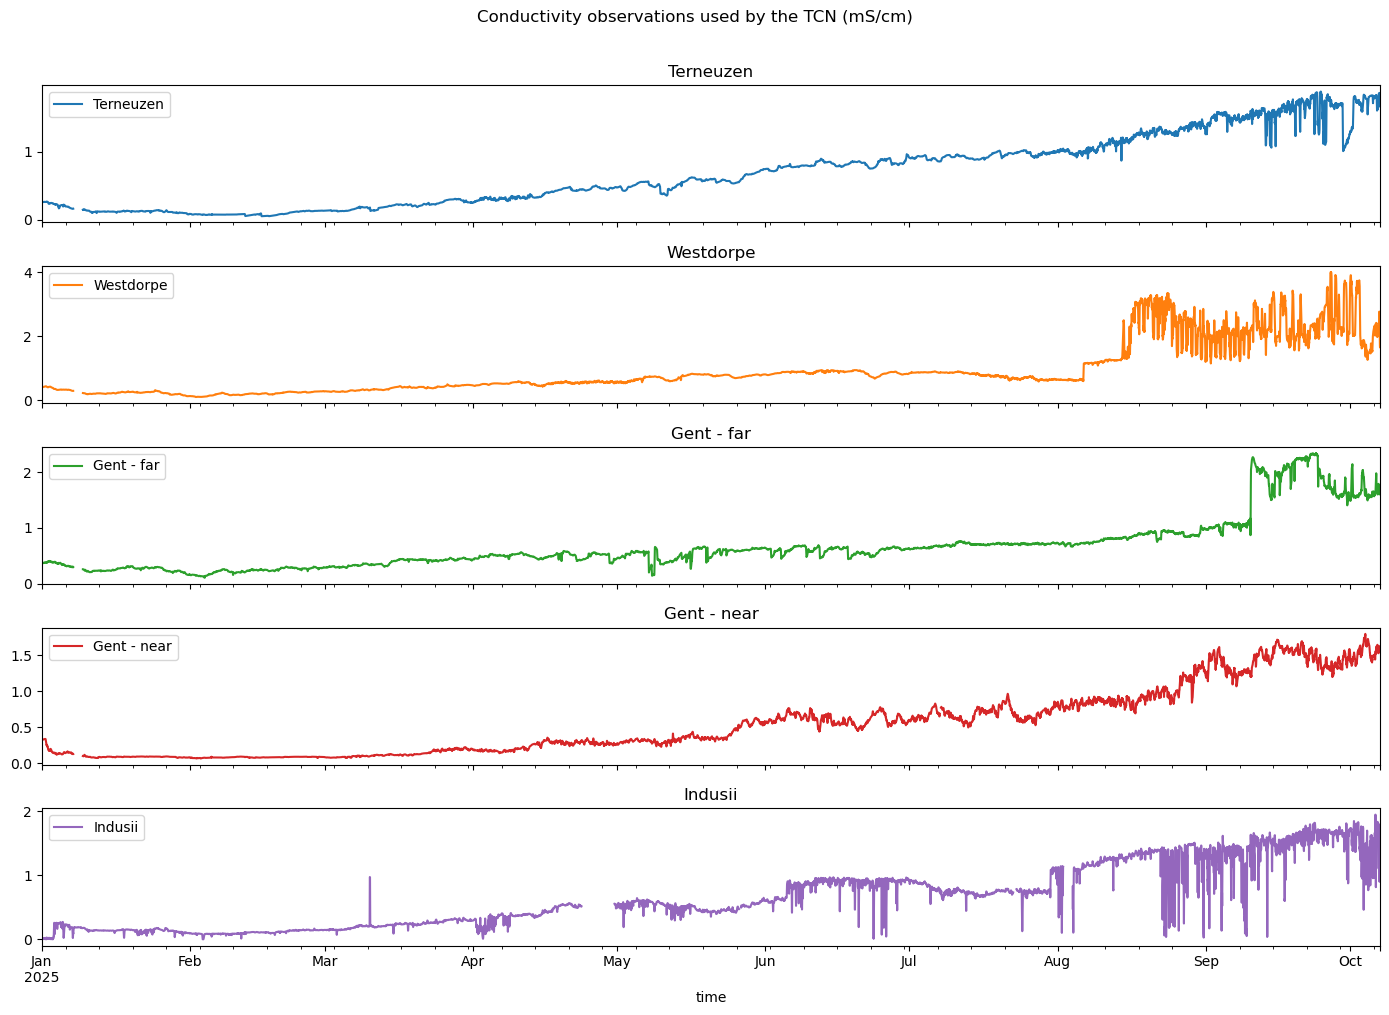

In [3]:
data = wide[SENSOR_NAMES].apply(pd.to_numeric, errors='coerce')
first_observation = data.apply(pd.Series.first_valid_index)
last_observation = data.apply(pd.Series.last_valid_index)
common_start = first_observation.max()
common_end = last_observation.min()

data = data.loc[common_start:common_end].resample(f'{RESAMPLE_MINUTES}min').mean()
data = data.interpolate(method='time', limit=4, limit_area='inside')
data = data.rolling(window=2 * STEPS_PER_HOUR, min_periods=2 * STEPS_PER_HOUR).mean()

coverage = pd.DataFrame({
    'first observation': first_observation,
    'last observation': last_observation,
    'missing rows after short-gap fill': data.isna().sum(),
})
display(coverage)
print(f'Common period used: {common_start} to {common_end}')

data.plot(subplots=True, figsize=(14, 10), sharex=True, title=SENSOR_NAMES)
plt.suptitle('Conductivity observations used by the TCN (mS/cm)', y=1.01)
plt.tight_layout()
plt.show()

## 4. Scale the inputs and create time windows

One example contains a `72 hours × 5 sensors` input matrix. Its target is the change between the latest known Indusii value and the Indusii value at the forecast horizon.

Predicting a change makes persistence equal to a predicted change of zero. Scaling parameters are learned from January-July only.

In [ ]:
# Fit the scaler using complete training rows only.
training_rows = data.loc[TRAIN_PERIOD[0]:TRAIN_PERIOD[1], SENSOR_NAMES].dropna()
scaler = StandardScaler().fit(training_rows)
scaled_values = scaler.transform(data[SENSOR_NAMES]).astype('float32')
target_values = data[TARGET].to_numpy(dtype='float32')
timestamps = data.index

def make_windows(period):
    """Return complete 72-hour histories and one future Indusii change."""
    period_start = pd.Timestamp(period[0], tz='UTC')
    period_end = pd.Timestamp(period[1], tz='UTC')
    X, y, current, forecast_times = [], [], [], []

    # s is the first time step after the input history.
    for s in range(LOOKBACK_STEPS, len(data) - FORECAST_STEPS + 1):
        forecast_index = s + FORECAST_STEPS - 1
        forecast_time = timestamps[forecast_index]
        if not (period_start <= forecast_time <= period_end):
            continue

        history = scaled_values[s - LOOKBACK_STEPS:s]
        latest_target = target_values[s - 1]
        future_target = target_values[forecast_index]
        if not (np.isfinite(history).all() and np.isfinite(latest_target) and np.isfinite(future_target)):
            continue

        X.append(history)
        y.append(future_target - latest_target)
        current.append(latest_target)
        forecast_times.append(forecast_time)

    return (
        np.asarray(X, dtype='float32'),
        np.asarray(y, dtype='float32'),
        np.asarray(current, dtype='float32'),
        pd.DatetimeIndex(forecast_times),
    )

X_train, y_train, current_train, time_train = make_windows(TRAIN_PERIOD)
X_val, y_val, current_val, time_val = make_windows(VALIDATION_PERIOD)
X_test, y_test, current_test, time_test = make_windows(TEST_PERIOD)

# Scale only the target change; convert it back after prediction.
target_scale = float(y_train.std())
if target_scale < 1e-6:
    raise RuntimeError('Training target has almost no variation.')
y_train_scaled = y_train / target_scale
y_val_scaled = y_val / target_scale

print('X shape means: examples, historical time steps, sensors')
print('Training:  ', X_train.shape, y_train.shape)
print('Validation:', X_val.shape, y_val.shape)
print('Testing:   ', X_test.shape, y_test.shape)

X shape means: examples, historical time steps, sensors
Training:   (16244, 288, 5) (16244,)
Validation: (2484, 288, 5) (2484,)
Testing:    (2880, 288, 5) (2880,)


## 5. Build the TCN

A **causal** convolution only uses the present and past. A **dilated** convolution skips through the history, allowing deeper layers to examine increasingly distant observations. Dilation rates `1, 2, 4, 8, 16, 32` give this small model access to the complete 72-hour window.

The output layer starts with zero weights. Before learning anything, the predicted change is therefore zero—the persistence forecast.

In [5]:
def residual_block(x, dilation, filters=24, kernel_size=5):
    """Two causal convolutions plus a shortcut connection."""
    shortcut = x
    if x.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, 1, padding='same')(shortcut)

    for _ in range(2):
        x = layers.Conv1D(
            filters, kernel_size, padding='causal', dilation_rate=dilation
        )(x)
        x = layers.LayerNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.SpatialDropout1D(0.10)(x)

    return layers.Activation('relu')(layers.Add()([x, shortcut]))

def build_tcn():
    inputs = layers.Input(shape=(LOOKBACK_STEPS, len(SENSOR_NAMES)), name='sensor_history')
    x = inputs
    for dilation in [1, 2, 4, 8, 16, 32]:
        x = residual_block(x, dilation)

    # The final encoded time step summarises the historical window.
    x = layers.Lambda(lambda sequence: sequence[:, -1, :], name='latest_encoding')(x)
    x = layers.Dense(32, activation='relu')(x)
    output = layers.Dense(
        1, kernel_initializer='zeros', bias_initializer='zeros', name='scaled_change'
    )(x)
    return Model(inputs, output, name='simple_salinity_tcn')

model = build_tcn()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4, clipnorm=1.0),
    loss=tf.keras.losses.Huber(delta=1.0),
    metrics=[tf.keras.metrics.MeanAbsoluteError(name='scaled_mae')],
)
model.summary()

Model: "simple_salinity_tcn"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sensor_history      │ (None, 288, 5)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 288, 24)   │        624 │ sensor_history[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 288, 24)   │         48 │ conv1d_1[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 288, 24)   │          0 │ layer_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 288, 24)   │          0 │ activation[0][0]  │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 288, 24)   │      2,904 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 288, 24)   │         48 │ conv1d_2[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 288, 24)   │          0 │ layer_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_1 │ (None, 288, 24)   │          0 │ activation_1[0][… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 288, 24)   │        144 │ sensor_history[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 288, 24)   │          0 │ spatial_dropout1… │
│                     │                   │            │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 288, 24)   │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 288, 24)   │      2,904 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 288, 24)   │         48 │ conv1d_3[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 288, 24)   │          0 │ layer_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_2 │ (None, 288, 24)   │          0 │ activation_3[0][… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 288, 24)   │      2,904 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 288, 24)   │         48 │ conv1d_4[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 34,121 (133.29 KB)

 Trainable params: 34,121 (133.29 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Train the model

Early stopping monitors August and restores the weights from the best validation epoch. September is not used during training or model selection.

After training, one simple validation weight between 0 and 1 controls how much of the learned correction is trusted. A weight of 0 gives persistence; a weight of 1 uses the complete TCN correction.

Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 26s 305ms/step - loss: 0.2027 - scaled_mae: 0.3838 - val_loss: 1.9338 - val_scaled_mae: 2.2554 - learning_rate: 3.0000e-04
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 19s 301ms/step - loss: 0.2020 - scaled_mae: 0.3828 - val_loss: 1.9308 - val_scaled_mae: 2.2548 - learning_rate: 3.0000e-04
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 20s 306ms/step - loss: 0.1997 - scaled_mae: 0.3810 - val_loss: 1.9208 - val_scaled_mae: 2.2508 - learning_rate: 3.0000e-04
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 19s 300ms/step - loss: 0.1929 - scaled_mae: 0.3773 - val_loss: 1.8867 - val_scaled_mae: 2.2179 - learning_rate: 3.0000e-04
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 20s 305ms/step - loss: 0.1843 - scaled_mae: 0.3729 - val_loss: 1.8586 - val_scaled_mae: 2.1936 - learning_rate: 3.0000e-04
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 21s 331ms/step - loss: 0.1741 - scaled_mae: 0.3625 - val_loss: 1.8146 - val_scaled_mae: 2.1389 - learning_rate: 3.0000e-04
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━

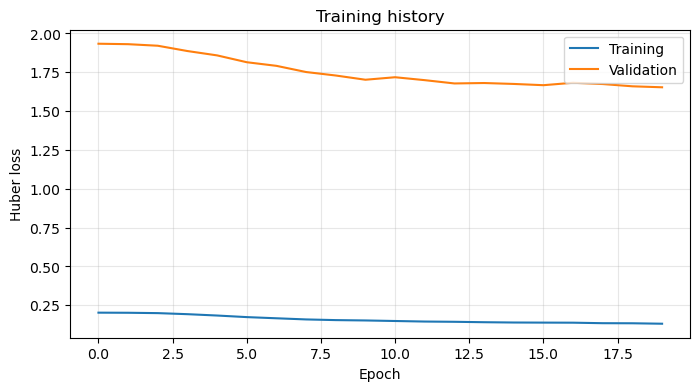

In [6]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', patience=3, factor=0.5, min_lr=1e-6
    ),
]

history = model.fit(
    X_train,
    y_train_scaled,
    validation_data=(X_val, y_val_scaled),
    epochs=20,
    batch_size=256,
    callbacks=callbacks,
    verbose=1,
)

plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Training')
plt.plot(history.history['val_loss'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Huber loss')
plt.title('Training history')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## 7. Evaluate against persistence

Persistence assumes the latest conductivity remains unchanged. The TCN should only be considered useful when its errors are lower than persistence on September. Positive RMSE skill means the TCN is better.

In [7]:
# Use August to decide how strongly the TCN correction should be trusted.
validation_change = model.predict(X_val, batch_size=256, verbose=0).ravel() * target_scale
denominator = np.sum(validation_change ** 2)
correction_weight = 0.0 if denominator < 1e-12 else np.sum(validation_change * y_val) / denominator
correction_weight = float(np.clip(correction_weight, 0.0, 1.0))

raw_test_change = model.predict(X_test, batch_size=256, verbose=0).ravel() * target_scale
predicted_change = correction_weight * raw_test_change
actual = current_test + y_test
tcn_prediction = current_test + predicted_change
persistence_prediction = current_test.copy()

def scores(name, prediction):
    return {
        'model': name,
        'MAE (mS/cm)': mean_absolute_error(actual, prediction),
        'RMSE (mS/cm)': np.sqrt(mean_squared_error(actual, prediction)),
        'R²': r2_score(actual, prediction),
    }

metrics = pd.DataFrame([
    scores('TCN', tcn_prediction),
    scores('Persistence', persistence_prediction),
])
tcn_rmse = metrics.loc[metrics['model'] == 'TCN', 'RMSE (mS/cm)'].iloc[0]
persistence_rmse = metrics.loc[metrics['model'] == 'Persistence', 'RMSE (mS/cm)'].iloc[0]
skill = 1 - tcn_rmse / persistence_rmse
display(metrics.round(4))
print(f'Validation trust weight for the learned correction: {correction_weight:.3f}')
print(f'RMSE skill relative to persistence: {skill:.2%}')
if skill <= 0:
    print('The TCN did not beat persistence. Do not claim an accuracy improvement for this run.')

,model,MAE (mS/cm),RMSE (mS/cm),R²
0,TCN,0.1555,0.2543,0.2106
1,Persistence,0.1665,0.2812,0.0344


Validation trust weight for the learned correction: 1.000
RMSE skill relative to persistence: 9.58%


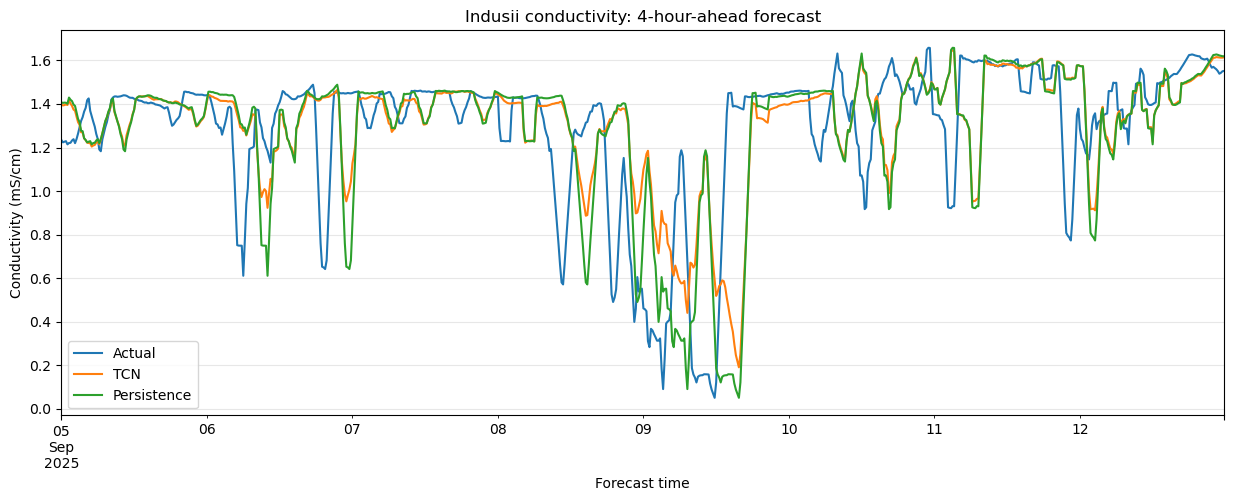

In [8]:
predictions = pd.DataFrame({
    'Actual': actual,
    'TCN': tcn_prediction,
    'Persistence': persistence_prediction,
}, index=time_test)

week = predictions.loc['2025-09-05':'2025-09-12']
week.plot(figsize=(15, 5), linewidth=1.5)
plt.title(f'Indusii conductivity: {FORECAST_HOURS}-hour-ahead forecast')
plt.xlabel('Forecast time')
plt.ylabel('Conductivity (mS/cm)')
plt.grid(alpha=0.3)
plt.show()

## 8. Which propagation delays did the TCN use?

The network has not been given a fixed 42-hour delay. To inspect its behaviour, the following experiment hides one four-hour historical block from one sensor at a time by replacing its scaled values with zero—the training mean.

If masking a block increases RMSE, that lag range was useful to the trained model. This is a model-sensitivity result, not direct proof of water travel time or causality. Correlated sensors can also substitute for one another, so importance may be shared between locations.

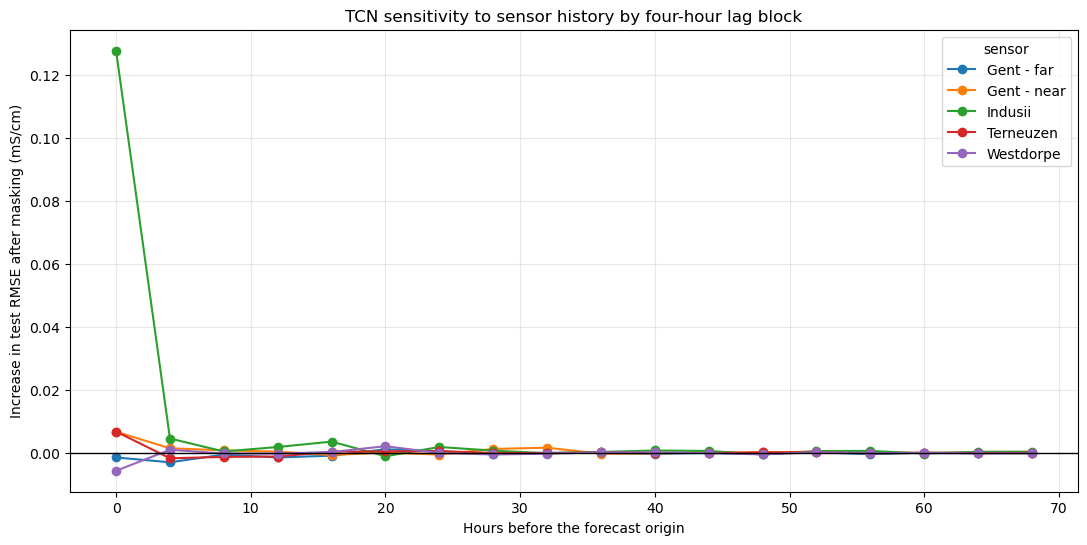

The ten lag blocks whose removal harmed the model most:


,sensor,lag_start_hours,lag_end_hours,RMSE increase
72,Indusii,0,4,0.12769
0,Terneuzen,0,4,0.00667
54,Gent - near,0,4,0.00663
73,Indusii,4,8,0.00448
76,Indusii,16,20,0.00349
23,Westdorpe,20,24,0.00204
78,Indusii,24,28,0.00178
75,Indusii,12,16,0.00177
62,Gent - near,32,36,0.00156
55,Gent - near,4,8,0.00137


In [9]:
BLOCK_HOURS = 4
base_rmse = np.sqrt(mean_squared_error(actual, tcn_prediction))
importance_rows = []

for sensor_index, sensor_name in enumerate(SENSOR_NAMES):
    for lag_start in range(0, LOOKBACK_HOURS, BLOCK_HOURS):
        lag_end = lag_start + BLOCK_HOURS
        # lag 0-4 h is the newest block; lag 68-72 h is the oldest.
        column_start = LOOKBACK_STEPS - lag_end * STEPS_PER_HOUR
        column_end = LOOKBACK_STEPS - lag_start * STEPS_PER_HOUR

        masked = X_test.copy()
        masked[:, column_start:column_end, sensor_index] = 0.0
        masked_change = (
            correction_weight
            * model.predict(masked, batch_size=256, verbose=0).ravel()
            * target_scale
        )
        masked_prediction = current_test + masked_change
        masked_rmse = np.sqrt(mean_squared_error(actual, masked_prediction))

        importance_rows.append({
            'sensor': sensor_name,
            'lag_start_hours': lag_start,
            'lag_end_hours': lag_end,
            'RMSE increase': masked_rmse - base_rmse,
        })

lag_importance = pd.DataFrame(importance_rows)
importance_table = lag_importance.pivot(
    index='lag_start_hours', columns='sensor', values='RMSE increase'
)
importance_table.plot(figsize=(13, 6), marker='o')
plt.axhline(0, color='black', linewidth=1)
plt.xlabel('Hours before the forecast origin')
plt.ylabel('Increase in test RMSE after masking (mS/cm)')
plt.title('TCN sensitivity to sensor history by four-hour lag block')
plt.grid(alpha=0.3)
plt.show()

print('The ten lag blocks whose removal harmed the model most:')
display(lag_importance.sort_values('RMSE increase', ascending=False).head(10).round(5))

## 9. Reading the result responsibly

- A peak around 40-48 hours for Terneuzen would be consistent with the earlier propagation hypothesis, but the model was free to choose it.
- A peak elsewhere means that another part of the history was more useful for this trained model and test month.
- A flat or noisy importance profile means the data do not identify a stable delay clearly.
- Positive test skill is required before interpreting the TCN as an improvement over persistence.
- Repeat the experiment across several chronological test periods before drawing a physical conclusion.

This notebook predicts one endpoint to remain easy to understand. To change the task, edit `FORECAST_HOURS` near the top and run all cells again.